In [ ]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [ ]:
PCA_LOOKBACK = 252
N_PCA_FACTORS = 15
OU_WINDOW = 60

ENTRY_THRESHOLD = 1.25
LONG_EXIT_THRESHOLD = 0.50
SHORT_EXIT_THRESHOLD = 0.75
KAPPA_MIN = 8.4

TRANSACTION_COST_BPS = 5
TRANSACTION_COST = TRANSACTION_COST_BPS / 10000

In [ ]:
# Load Prices
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  # use latest available date

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# with auto_adjust=True, use Close
prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]

Number of tickers in universe: 102


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ZI: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found

3 Failed downloads:
['ZI', 'ANSS', 'JNPR']: possibly delisted; no timezone found


In [ ]:
# Compute Daily Returns

returns = prices.pct_change(fill_method=None)

In [ ]:
# Build Rolling 1 Year windows
valid_dates = returns.index[PCA_LOOKBACK:]
print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2071
Number of valid PCA dates: 1819
First PCA date: 2019-01-03 00:00:00


In [ ]:
# Build rolling window index + precompute arrays

window = PCA_LOOKBACK

# integer positions where we can run PCA
valid_pos = np.arange(window, len(returns.index))

# matching dates, just for output / plotting
valid_dates = returns.index[valid_pos]

# precompute once
returns_np = returns.to_numpy()
returns_filled_np = returns.fillna(0.0).to_numpy()
dates_np = returns.index.to_numpy()
col_names = returns.columns.to_numpy()
col_index_map = {col: i for i, col in enumerate(col_names)}

print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2071
Number of valid PCA dates: 1819
First PCA date: 2019-01-03 00:00:00


In [ ]:
    # =========================
    # BASELINE BACKTEST
    # =========================
def run_backtest(ENTRY_THRESHOLD, LONG_EXIT_THRESHOLD, SHORT_EXIT_THRESHOLD,KAPPA_MIN,N_PCA_FACTORS, OU_WINDOW):
    pnl_series = []
    turnover_series = []
    active_count_series = []

    # NEW
    long_count_series = []
    short_count_series = []

    # persistent state
    positions = {}        # stock -> +1 or -1
    weights_prev = {}     # stock -> portfolio weight


    for i in valid_pos:

        # ---------------------------------
        # 1) Build rolling PCA factor model
        # ---------------------------------
        window_slice = returns_np[i - PCA_LOOKBACK + 1 : i + 1, :]
        valid_mask = ~np.isnan(window_slice).any(axis=0)

        if valid_mask.sum() < N_PCA_FACTORS + 1:
            pnl_series.append(0.0)
            turnover_series.append(0.0)
            active_count_series.append(0)
            long_count_series.append(0)
            short_count_series.append(0)
            continue

        window_data = window_slice[:, valid_mask]
        valid_col_idx = np.where(valid_mask)[0]
        valid_col_names = col_names[valid_col_idx]

        mu = np.mean(window_data, axis=0)
        sigma = np.std(window_data, axis=0, ddof=1)

        sigma_mask = np.isfinite(sigma) & (sigma > 0)
        window_data = window_data[:, sigma_mask]
        sigma = sigma[sigma_mask]
        valid_col_idx = valid_col_idx[sigma_mask]
        valid_col_names = valid_col_names[sigma_mask]

        if window_data.shape[1] < N_PCA_FACTORS + 1:
            pnl_series.append(0.0)
            turnover_series.append(0.0)
            active_count_series.append(0)
            long_count_series.append(0)
            short_count_series.append(0)
            continue

        Y = (window_data - mu[sigma_mask]) / sigma

        corr = np.corrcoef(Y, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(corr)
        idx = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx]

        V = eigvecs[:, :N_PCA_FACTORS]
        Q = V / sigma[:, None]

        F = window_data @ Q

        reg_window = window_data[-OU_WINDOW:, :]
        F_reg = F[-OU_WINDOW:, :]

        # ---------------------------------
        # 2) Estimate OU objects
        # ---------------------------------
        m_values = {}
        sigma_eq_values = {}
        s_values = {}

        X_factor = sm.add_constant(F_reg, has_constant="add")
        beta_dict = {}

        for j, stock in enumerate(valid_col_names):

            y = reg_window[:, j]
            model = sm.OLS(y, X_factor).fit()
            betas = model.params[1:]   # exclude intercept
            beta_dict[stock] = betas
            resid = model.resid
            X_series = np.cumsum(resid)

            X_lag = X_series[:-1]
            X_now = X_series[1:]

            if len(X_lag) < 10:
                continue

            X_reg = sm.add_constant(X_lag, has_constant="add")
            ar = sm.OLS(X_now, X_reg).fit()

            a = ar.params[0]
            b = ar.params[1]

            if not (0 < b < 1):
                continue

            kappa = -np.log(b) * 252
            if kappa <= KAPPA_MIN:
                continue

            zeta = ar.resid
            zeta_var = np.var(zeta, ddof=1)
            sigma_eq = np.sqrt(zeta_var / (1 - b**2))

            if not np.isfinite(sigma_eq) or sigma_eq <= 0:
                continue

            m = a / (1 - b)

            m_values[stock] = m
            sigma_eq_values[stock] = sigma_eq

        # ---------------------------------
        # EMPTY CASE
        # ---------------------------------
        if len(m_values) == 0:
            target_weights = {}

            turnover = sum(
                abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
                for n in set(weights_prev) | set(target_weights)
            )

            trading_cost = TRANSACTION_COST * turnover

            pnl_series.append(-trading_cost)
            turnover_series.append(turnover)
            active_count_series.append(0)
            long_count_series.append(0)
            short_count_series.append(0)

            positions = {}
            weights_prev = {}
            continue

        # ---------------------------------
        # 3) s-score
        # ---------------------------------
        m_bar = np.mean(list(m_values.values()))

        for stock in m_values.keys():
            m_adj = m_values[stock] - m_bar
            s = -m_adj / sigma_eq_values[stock]
            s_values[stock] = s

        # ---------------------------------
        # 4) positions
        # ---------------------------------
        new_positions = positions.copy()

        for stock in list(new_positions.keys()):
            if stock not in s_values:
                new_positions.pop(stock)

        for stock, s in s_values.items():
            pos = new_positions.get(stock, 0)

            if pos == 0:
                if s < -ENTRY_THRESHOLD:
                    new_positions[stock] = 1
                elif s > ENTRY_THRESHOLD:
                    new_positions[stock] = -1

            elif pos == 1 and s > -LONG_EXIT_THRESHOLD:
                new_positions.pop(stock)

            elif pos == -1 and s < SHORT_EXIT_THRESHOLD:
                new_positions.pop(stock)

        positions = new_positions

        # ---------------------------------
        # 5) FACTOR-NEUTRAL BANG-BANG PORTFOLIO
        # ---------------------------------
        longs = [s for s, p in positions.items() if p == 1]
        shorts = [s for s, p in positions.items() if p == -1]

        target_weights = {}

        active_names = longs + shorts
        n_active = len(active_names)

        if n_active > 0:

            # equal notional (bang-bang)
            w = 1.0 / n_active

            # --- STOCK LEGS ---
            for stock in longs:
                target_weights[stock] = +w

            for stock in shorts:
                target_weights[stock] = -w

            # --- FACTOR HEDGE ---
            factor_exposure = np.zeros(N_PCA_FACTORS)

            for stock in active_names:
                beta = beta_dict.get(stock)
                if beta is None:
                    continue

                sign = target_weights[stock]
                factor_exposure += sign * beta

            for k in range(N_PCA_FACTORS):
                hedge_name = f"FACTOR_{k}"
                target_weights[hedge_name] = -factor_exposure[k]

        else:
            target_weights = {}
            positions = {}

        # track stock counts only
        long_count_series.append(len(longs))
        short_count_series.append(len(shorts))

        # ---------------------------------
        # 6) turnover
        # ---------------------------------
        turnover = sum(
            abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
            for n in set(weights_prev) | set(target_weights)
        )

        trading_cost = TRANSACTION_COST * turnover

        # ---------------------------------
        # 7) pnl
        # ---------------------------------
        if i + 1 >= len(returns_np):
            pnl_series.append(-trading_cost)
            turnover_series.append(turnover)
            active_count_series.append(len(active_names))
            break

        next_ret = returns_np[i + 1]

        gross_pnl = 0.0

        for name, w in target_weights.items():

            # STOCK
            if name in col_index_map:
                r = next_ret[col_index_map[name]]
                if not np.isnan(r):
                    gross_pnl += w * r

            # FACTOR
            elif name.startswith("FACTOR_"):
                k = int(name.split("_")[1])
                factor_ret = next_ret[valid_col_idx] @ Q[:, k]
                gross_pnl += w * factor_ret

        net_pnl = gross_pnl - trading_cost

        pnl_series.append(net_pnl)
        turnover_series.append(turnover)
        active_count_series.append(len(active_names))

        weights_prev = target_weights.copy()

    # =========================
    # OUTPUT
    # =========================
    out_dates = valid_dates[:len(pnl_series)]

    pnl_series = pd.Series(pnl_series, index=out_dates)
    turnover_series = pd.Series(turnover_series, index=out_dates)
    active_count_series = pd.Series(active_count_series, index=out_dates)

    long_count_series = pd.Series(long_count_series, index=out_dates)
    short_count_series = pd.Series(short_count_series, index=out_dates)


    # =========================
    # PERFORMANCE + POSITION METRICS
    # =========================

    ret = pnl_series.copy()

    # ----- BASIC -----
    mean_daily = ret.mean()
    std_daily = ret.std()

    ann_factor = 252
    mean_annual = mean_daily * ann_factor
    vol_annual = std_daily * np.sqrt(ann_factor)

    sharpe = mean_annual / vol_annual if vol_annual > 0 else np.nan

    # ----- EQUITY CURVE -----
    cum_returns = (1 + ret).cumprod()

    running_max = cum_returns.cummax()
    drawdown = cum_returns / running_max - 1
    max_dd = drawdown.min()

    calmar = mean_annual / abs(max_dd) if max_dd != 0 else np.nan

    # ----- TRADE QUALITY -----
    win_rate = (ret > 0).mean()
    avg_win = ret[ret > 0].mean()
    avg_loss = ret[ret < 0].mean()

    gross_profit = ret[ret > 0].sum()
    gross_loss = ret[ret < 0].sum()
    profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan

    # ----- POSITION STATS -----
    avg_longs = long_count_series.mean()
    avg_shorts = short_count_series.mean()
    avg_positions = active_count_series.mean()

    long_short_ratio = avg_longs / avg_shorts if avg_shorts > 0 else np.nan
    pct_days_active = (active_count_series > 0).mean()

    # ----- TURNOVER / ACTIVITY -----
    avg_turnover = turnover_series.mean()
    pct_trading_days = (turnover_series > 0).mean()
    return {
    "sharpe": sharpe,
    "pnl_series": pnl_series,
    "mean_annual": mean_annual,
    "vol_annual": vol_annual,
    "max_dd": max_dd,
    "calmar": calmar,
    "win_rate": win_rate,
    "avg_win": avg_win,
    "avg_loss": avg_loss,
    "profit_factor": profit_factor,
    "avg_longs": avg_longs,
    "avg_shorts": avg_shorts,
    "avg_positions": avg_positions,
    "long_short_ratio": long_short_ratio,
    "pct_days_active": pct_days_active,
    "avg_turnover": avg_turnover,
    "pct_trading_days": pct_trading_days
}

In [ ]:


def print_full_report(res, title):

    pnl = res["pnl_series"]
    cum = (1 + pnl).cumprod()

    # ===== PLOT =====
    plt.figure()
    cum.plot()
    plt.title(title + " Equity Curve")
    plt.show()

    # ===== PRINT =====
    print(f"\n========== {title} ==========\n")

    print("---- PERFORMANCE ----")
    print(f"Annual Return     : {res['mean_annual']:.4f}")
    print(f"Annual Vol        : {res['vol_annual']:.4f}")
    print(f"Sharpe Ratio      : {res['sharpe']:.4f}")
    print(f"Max Drawdown      : {res['max_dd']:.4f}")
    print(f"Calmar Ratio      : {res['calmar']:.4f}")

    print("\n---- TRADE QUALITY ----")
    print(f"Win Rate          : {res['win_rate']:.4f}")
    print(f"Avg Win           : {res['avg_win']:.5f}")
    print(f"Avg Loss          : {res['avg_loss']:.5f}")
    print(f"Profit Factor     : {res['profit_factor']:.4f}")

    print("\n---- POSITION STATS ----")
    print(f"Avg Longs         : {res['avg_longs']:.2f}")
    print(f"Avg Shorts        : {res['avg_shorts']:.2f}")
    print(f"Avg Positions     : {res['avg_positions']:.2f}")
    print(f"Long/Short Ratio  : {res['long_short_ratio']:.2f}")
    print(f"% Days Active     : {res['pct_days_active']:.2f}")

    print("\n---- ACTIVITY ----")
    print(f"Avg Turnover      : {res['avg_turnover']:.4f}")
    print(f"% Trading Days    : {res['pct_trading_days']:.2f}")

In [ ]:
# ===== BASELINE RUN =====
baseline_params = {
    "ENTRY": 1.25,
    "LONG_EXIT": 0.50,
    "SHORT_EXIT": 0.75,
    "KAPPA": 8.4,
    "PCA": 15,
    "OU": 60
}

baseline = run_backtest(
    baseline_params["ENTRY"],
    baseline_params["LONG_EXIT"],
    baseline_params["SHORT_EXIT"],
    baseline_params["KAPPA"],
    baseline_params["PCA"],
    baseline_params["OU"]
)


def print_full_report(res, title):

    pnl = res["pnl_series"]
    cum = (1 + pnl).cumprod()

    # ===== PLOT =====
    plt.figure()
    cum.plot()
    plt.title(title + " Equity Curve")
    plt.show()

    # ===== PRINT =====
    print(f"\n========== {title} ==========\n")

    print("---- PERFORMANCE ----")
    print(f"Annual Return     : {res['mean_annual']:.4f}")
    print(f"Annual Vol        : {res['vol_annual']:.4f}")
    print(f"Sharpe Ratio      : {res['sharpe']:.4f}")
    print(f"Max Drawdown      : {res['max_dd']:.4f}")
    print(f"Calmar Ratio      : {res['calmar']:.4f}")

    print("\n---- TRADE QUALITY ----")
    print(f"Win Rate          : {res['win_rate']:.4f}")
    print(f"Avg Win           : {res['avg_win']:.5f}")
    print(f"Avg Loss          : {res['avg_loss']:.5f}")
    print(f"Profit Factor     : {res['profit_factor']:.4f}")

    print("\n---- POSITION STATS ----")
    print(f"Avg Longs         : {res['avg_longs']:.2f}")
    print(f"Avg Shorts        : {res['avg_shorts']:.2f}")
    print(f"Avg Positions     : {res['avg_positions']:.2f}")
    print(f"Long/Short Ratio  : {res['long_short_ratio']:.2f}")
    print(f"% Days Active     : {res['pct_days_active']:.2f}")

    print("\n---- ACTIVITY ----")
    print(f"Avg Turnover      : {res['avg_turnover']:.4f}")
    print(f"% Trading Days    : {res['pct_trading_days']:.2f}")

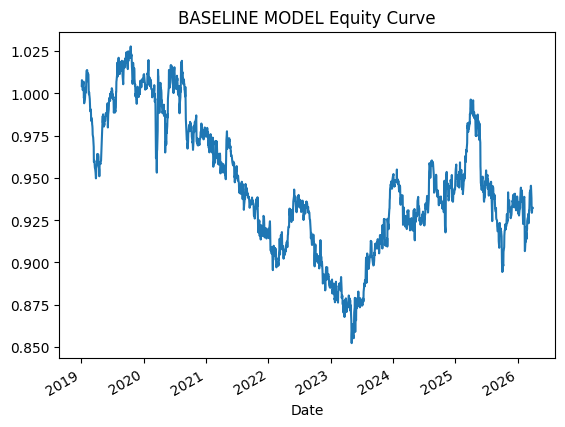


========== BASELINE MODEL ==========

---- PERFORMANCE ----
Annual Return     : -0.0076
Annual Vol        : 0.0647
Sharpe Ratio      : -0.1178
Max Drawdown      : -0.1708
Calmar Ratio      : -0.0446

---- TRADE QUALITY ----
Win Rate          : 0.4964
Avg Win           : 0.00298
Avg Loss          : -0.00300
Profit Factor     : 0.9800

---- POSITION STATS ----
Avg Longs         : 17.81
Avg Shorts        : 15.00
Avg Positions     : 32.81
Long/Short Ratio  : 1.19
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.2922
% Trading Days    : 1.00


In [13]:
print_full_report(baseline, "BASELINE MODEL")


===== GRID SEARCH =====

{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 8.4, 'PCA': 10, 'OU': 45} → Sharpe: -0.4531
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 8.4, 'PCA': 10, 'OU': 60} → Sharpe: -0.1802
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 8.4, 'PCA': 15, 'OU': 45} → Sharpe: -0.3583
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 8.4, 'PCA': 15, 'OU': 60} → Sharpe: -0.1178
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 10, 'OU': 45} → Sharpe: -0.4576
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 10, 'OU': 60} → Sharpe: -0.2675
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 15, 'OU': 45} → Sharpe: -0.4558
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 15, 'OU': 60} → Sharpe: 0.0178
{'ENTRY': 1.25, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 18, 'PCA': 10, 'OU': 45} → Sharpe: -0.7352
{'ENTRY': 1.25, '

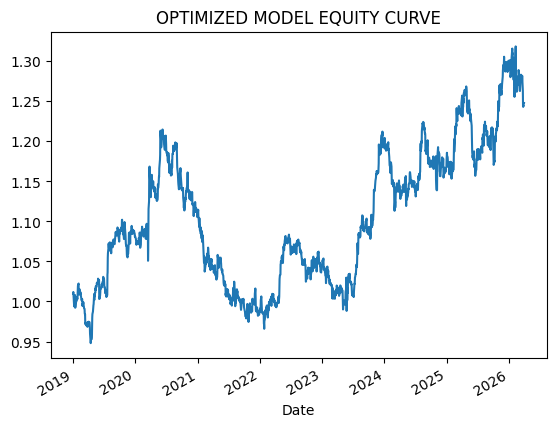


========== OPTIMIZED MODEL ==========

---- PERFORMANCE ----
Annual Return     : 0.0347
Annual Vol        : 0.0899
Sharpe Ratio      : 0.3861
Max Drawdown      : -0.2047
Calmar Ratio      : 0.1696

---- TRADE QUALITY ----
Win Rate          : 0.5151
Avg Win           : 0.00411
Avg Loss          : -0.00409
Profit Factor     : 1.0696

---- POSITION STATS ----
Avg Longs         : 8.57
Avg Shorts        : 7.20
Avg Positions     : 15.77
Long/Short Ratio  : 1.19
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.3300
% Trading Days    : 1.00


In [ ]:

# =========================
# PARAM GRID
# =========================
param_grid = {
    "ENTRY": [1.25, 1.5, 1.75],      # main driver
    "LONG_EXIT": [0.5],              # keep fixed for now
    "SHORT_EXIT": [0.75],            # keep fixed for now
    "KAPPA": [8.4, 12, 18],          # test stronger mean reversion
    "PCA": [10, 15],                 # small variation
    "OU": [45, 60]                   # slight variation
}

results = []

# =========================
# GRID SEARCH
# =========================
print("\n===== GRID SEARCH =====\n")

for combo in itertools.product(*param_grid.values()):
    
    params = dict(zip(param_grid.keys(), combo))

    res = run_backtest(
        params["ENTRY"],
        params["LONG_EXIT"],
        params["SHORT_EXIT"],
        params["KAPPA"],
        params["PCA"],
        params["OU"]
    )

    sharpe = res["sharpe"]

    results.append({
        "params": params,
        "res": res
    })

    print(f"{params} → Sharpe: {sharpe:.4f}")

# =========================
# BEST RESULT
# =========================
results = sorted(results, key=lambda x: x["res"]["sharpe"], reverse=True)
best = results[0]

print("\n===== BEST PARAMETERS =====")
for k, v in best["params"].items():
    print(f"{k}: {v}")

print(f"\nBEST SHARPE: {best['res']['sharpe']:.4f}")

# =========================
# PRINT FULL REPORT + PLOT
# =========================
res = best["res"]

pnl = res["pnl_series"]
cum = (1 + pnl).cumprod()

plt.figure()
cum.plot()
plt.title("OPTIMIZED MODEL EQUITY CURVE")
plt.show()

print("\n========== OPTIMIZED MODEL ==========\n")

print("---- PERFORMANCE ----")
print(f"Annual Return     : {res['mean_annual']:.4f}")
print(f"Annual Vol        : {res['vol_annual']:.4f}")
print(f"Sharpe Ratio      : {res['sharpe']:.4f}")
print(f"Max Drawdown      : {res['max_dd']:.4f}")
print(f"Calmar Ratio      : {res['calmar']:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {res['win_rate']:.4f}")
print(f"Avg Win           : {res['avg_win']:.5f}")
print(f"Avg Loss          : {res['avg_loss']:.5f}")
print(f"Profit Factor     : {res['profit_factor']:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {res['avg_longs']:.2f}")
print(f"Avg Shorts        : {res['avg_shorts']:.2f}")
print(f"Avg Positions     : {res['avg_positions']:.2f}")
print(f"Long/Short Ratio  : {res['long_short_ratio']:.2f}")
print(f"% Days Active     : {res['pct_days_active']:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {res['avg_turnover']:.4f}")
print(f"% Trading Days    : {res['pct_trading_days']:.2f}")


===== REFINED GRID SEARCH =====

{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 10, 'PCA': 14, 'OU': 55} → Sharpe: -0.3028
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 10, 'PCA': 14, 'OU': 60} → Sharpe: -0.0875
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 10, 'PCA': 15, 'OU': 55} → Sharpe: -0.2632
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 10, 'PCA': 15, 'OU': 60} → Sharpe: 0.1353
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 14, 'OU': 55} → Sharpe: -0.4061
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 14, 'OU': 60} → Sharpe: 0.0101
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 15, 'OU': 55} → Sharpe: -0.4122
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 12, 'PCA': 15, 'OU': 60} → Sharpe: 0.2114
{'ENTRY': 1.65, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.75, 'KAPPA': 14, 'PCA': 14, 'OU': 55} → Sharpe: -0.4734
{'ENTRY': 1.65,

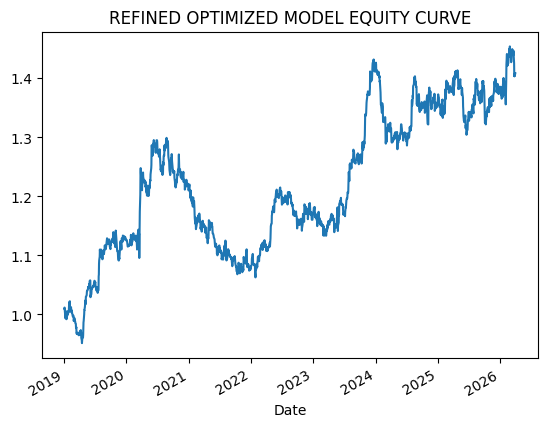


========== REFINED OPTIMIZED MODEL ==========

---- PERFORMANCE ----
Annual Return     : 0.0515
Annual Vol        : 0.0900
Sharpe Ratio      : 0.5726
Max Drawdown      : -0.1819
Calmar Ratio      : 0.2832

---- TRADE QUALITY ----
Win Rate          : 0.5162
Avg Win           : 0.00419
Avg Loss          : -0.00405
Profit Factor     : 1.1044

---- POSITION STATS ----
Avg Longs         : 8.08
Avg Shorts        : 6.72
Avg Positions     : 14.80
Long/Short Ratio  : 1.20
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.3526
% Trading Days    : 1.00


In [ ]:


# =========================
# REFINED GRID (ZOOM IN)
# =========================

param_grid = {
    "ENTRY": [1.65, 1.75, 1.85],
    "LONG_EXIT": [0.5],
    "SHORT_EXIT": [0.75],
    "KAPPA": [10, 12, 14],
    "PCA": [14, 15],
    "OU": [55, 60]
}

results = []

print("\n===== REFINED GRID SEARCH =====\n")

for combo in itertools.product(*param_grid.values()):
    
    params = dict(zip(param_grid.keys(), combo))

    res = run_backtest(
        params["ENTRY"],
        params["LONG_EXIT"],
        params["SHORT_EXIT"],
        params["KAPPA"],
        params["PCA"],
        params["OU"]
    )

    sharpe = res["sharpe"]

    results.append({
        "params": params,
        "res": res
    })

    print(f"{params} → Sharpe: {sharpe:.4f}")

# =========================
# BEST RESULT
# =========================
results = sorted(results, key=lambda x: x["res"]["sharpe"], reverse=True)
best = results[0]

print("\n===== BEST PARAMETERS (REFINED) =====")
for k, v in best["params"].items():
    print(f"{k}: {v}")

print(f"\nBEST SHARPE: {best['res']['sharpe']:.4f}")

# =========================
# REPORT + PLOT
# =========================
res = best["res"]

pnl = res["pnl_series"]
cum = (1 + pnl).cumprod()

plt.figure()
cum.plot()
plt.title("REFINED OPTIMIZED MODEL EQUITY CURVE")
plt.show()

print("\n========== REFINED OPTIMIZED MODEL ==========\n")

print("---- PERFORMANCE ----")
print(f"Annual Return     : {res['mean_annual']:.4f}")
print(f"Annual Vol        : {res['vol_annual']:.4f}")
print(f"Sharpe Ratio      : {res['sharpe']:.4f}")
print(f"Max Drawdown      : {res['max_dd']:.4f}")
print(f"Calmar Ratio      : {res['calmar']:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {res['win_rate']:.4f}")
print(f"Avg Win           : {res['avg_win']:.5f}")
print(f"Avg Loss          : {res['avg_loss']:.5f}")
print(f"Profit Factor     : {res['profit_factor']:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {res['avg_longs']:.2f}")
print(f"Avg Shorts        : {res['avg_shorts']:.2f}")
print(f"Avg Positions     : {res['avg_positions']:.2f}")
print(f"Long/Short Ratio  : {res['long_short_ratio']:.2f}")
print(f"% Days Active     : {res['pct_days_active']:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {res['avg_turnover']:.4f}")
print(f"% Trading Days    : {res['pct_trading_days']:.2f}")


===== REFINED GRID SEARCH =====

{'ENTRY': 1.75, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 14, 'PCA': 15, 'OU': 60} → Sharpe: 0.5966
{'ENTRY': 1.75, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 16, 'PCA': 15, 'OU': 60} → Sharpe: 0.2499
{'ENTRY': 1.75, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 18, 'PCA': 15, 'OU': 60} → Sharpe: 0.1978
{'ENTRY': 1.75, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 20, 'PCA': 15, 'OU': 60} → Sharpe: 0.0622
{'ENTRY': 1.8, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 14, 'PCA': 15, 'OU': 60} → Sharpe: 0.5204
{'ENTRY': 1.8, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 16, 'PCA': 15, 'OU': 60} → Sharpe: 0.1913
{'ENTRY': 1.8, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 18, 'PCA': 15, 'OU': 60} → Sharpe: 0.1296
{'ENTRY': 1.8, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 20, 'PCA': 15, 'OU': 60} → Sharpe: 0.0113
{'ENTRY': 1.85, 'LONG_EXIT': 0.5, 'SHORT_EXIT': 0.7, 'KAPPA': 14, 'PCA': 15, 'OU': 60} → Sharpe: 0.3047
{'ENTRY': 1.85, 'LONG_EXIT': 0.5, 

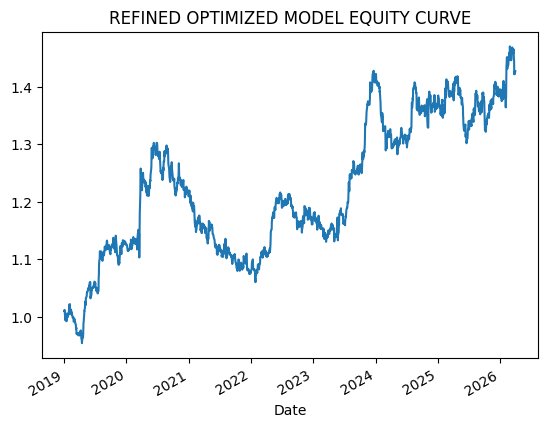


========== REFINED OPTIMIZED MODEL ==========

---- PERFORMANCE ----
Annual Return     : 0.0533
Annual Vol        : 0.0893
Sharpe Ratio      : 0.5966
Max Drawdown      : -0.1862
Calmar Ratio      : 0.2861

---- TRADE QUALITY ----
Win Rate          : 0.5179
Avg Win           : 0.00414
Avg Loss          : -0.00402
Profit Factor     : 1.1093

---- POSITION STATS ----
Avg Longs         : 8.08
Avg Shorts        : 6.96
Avg Positions     : 15.05
Long/Short Ratio  : 1.16
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.3461
% Trading Days    : 1.00


In [19]:
param_grid = {
    "ENTRY": [1.75, 1.8, 1.85, 1.95],          # tighten center
    "LONG_EXIT": [0.5],     # now refine exits
    "SHORT_EXIT": [0.7],
    "KAPPA": [14,16,18,20],              # test if 14 is peak
    "PCA": [15],                # confirm 15 optimal
    "OU": [60]                  # test stability of 60
}


results = []

print("\n===== REFINED GRID SEARCH =====\n")

for combo in itertools.product(*param_grid.values()):
    
    params = dict(zip(param_grid.keys(), combo))

    res = run_backtest(
        params["ENTRY"],
        params["LONG_EXIT"],
        params["SHORT_EXIT"],
        params["KAPPA"],
        params["PCA"],
        params["OU"]
    )

    sharpe = res["sharpe"]

    results.append({
        "params": params,
        "res": res
    })

    print(f"{params} → Sharpe: {sharpe:.4f}")

# =========================
# BEST RESULT
# =========================
results = sorted(results, key=lambda x: x["res"]["sharpe"], reverse=True)
best = results[0]

print("\n===== BEST PARAMETERS (REFINED) =====")
for k, v in best["params"].items():
    print(f"{k}: {v}")

print(f"\nBEST SHARPE: {best['res']['sharpe']:.4f}")

# =========================
# REPORT + PLOT
# =========================
res = best["res"]

pnl = res["pnl_series"]
cum = (1 + pnl).cumprod()

plt.figure()
cum.plot()
plt.title("REFINED OPTIMIZED MODEL EQUITY CURVE")
plt.show()

print("\n========== REFINED OPTIMIZED MODEL ==========\n")

print("---- PERFORMANCE ----")
print(f"Annual Return     : {res['mean_annual']:.4f}")
print(f"Annual Vol        : {res['vol_annual']:.4f}")
print(f"Sharpe Ratio      : {res['sharpe']:.4f}")
print(f"Max Drawdown      : {res['max_dd']:.4f}")
print(f"Calmar Ratio      : {res['calmar']:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {res['win_rate']:.4f}")
print(f"Avg Win           : {res['avg_win']:.5f}")
print(f"Avg Loss          : {res['avg_loss']:.5f}")
print(f"Profit Factor     : {res['profit_factor']:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {res['avg_longs']:.2f}")
print(f"Avg Shorts        : {res['avg_shorts']:.2f}")
print(f"Avg Positions     : {res['avg_positions']:.2f}")
print(f"Long/Short Ratio  : {res['long_short_ratio']:.2f}")
print(f"% Days Active     : {res['pct_days_active']:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {res['avg_turnover']:.4f}")
print(f"% Trading Days    : {res['pct_trading_days']:.2f}")

In [ ]:
param_grid = {
    "ENTRY": [1.6, 1.7, 1.75, 1.8, 1.9],     # wider around peak
    "LONG_EXIT": [0.4, 0.5, 0.6],           # now actually optimize exits
    "SHORT_EXIT": [0.65, 0.7, 0.75],        # refine short exit
    "KAPPA": [12, 14, 16, 18],              # test stability of peak
    "PCA": [14, 15, 16],                    # confirm robustness
    "OU": [55, 60, 65]                      # test regime sensitivity
}

results = []

print("\n===== REFINED GRID SEARCH =====\n")

for combo in itertools.product(*param_grid.values()):
    
    params = dict(zip(param_grid.keys(), combo))

    res = run_backtest(
        params["ENTRY"],
        params["LONG_EXIT"],
        params["SHORT_EXIT"],
        params["KAPPA"],
        params["PCA"],
        params["OU"]
    )

    sharpe = res["sharpe"]

    results.append({
        "params": params,
        "res": res
    })

    print(f"{params} → Sharpe: {sharpe:.4f}")

# =========================
# BEST RESULT
# =========================
results = sorted(results, key=lambda x: x["res"]["sharpe"], reverse=True)
best = results[0]

print("\n===== BEST PARAMETERS (REFINED) =====")
for k, v in best["params"].items():
    print(f"{k}: {v}")

print(f"\nBEST SHARPE: {best['res']['sharpe']:.4f}")

# =========================
# REPORT + PLOT
# =========================
res = best["res"]

pnl = res["pnl_series"]
cum = (1 + pnl).cumprod()

plt.figure()
cum.plot()
plt.title("REFINED OPTIMIZED MODEL EQUITY CURVE")
plt.show()

print("\n========== REFINED OPTIMIZED MODEL ==========\n")

print("---- PERFORMANCE ----")
print(f"Annual Return     : {res['mean_annual']:.4f}")
print(f"Annual Vol        : {res['vol_annual']:.4f}")
print(f"Sharpe Ratio      : {res['sharpe']:.4f}")
print(f"Max Drawdown      : {res['max_dd']:.4f}")
print(f"Calmar Ratio      : {res['calmar']:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {res['win_rate']:.4f}")
print(f"Avg Win           : {res['avg_win']:.5f}")
print(f"Avg Loss          : {res['avg_loss']:.5f}")
print(f"Profit Factor     : {res['profit_factor']:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {res['avg_longs']:.2f}")
print(f"Avg Shorts        : {res['avg_shorts']:.2f}")
print(f"Avg Positions     : {res['avg_positions']:.2f}")
print(f"Long/Short Ratio  : {res['long_short_ratio']:.2f}")
print(f"% Days Active     : {res['pct_days_active']:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {res['avg_turnover']:.4f}")
print(f"% Trading Days    : {res['pct_trading_days']:.2f}")


===== REFINED GRID SEARCH =====

{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 14, 'OU': 55} → Sharpe: -0.3012
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 14, 'OU': 60} → Sharpe: 0.2676
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 14, 'OU': 65} → Sharpe: 0.2357
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 15, 'OU': 55} → Sharpe: -0.3136
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 15, 'OU': 60} → Sharpe: 0.2108
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 15, 'OU': 65} → Sharpe: 0.3913
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 16, 'OU': 55} → Sharpe: -0.3032
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 16, 'OU': 60} → Sharpe: 0.0466
{'ENTRY': 1.6, 'LONG_EXIT': 0.4, 'SHORT_EXIT': 0.65, 'KAPPA': 12, 'PCA': 16, 'OU': 65} → Sharpe: 0.1712
{'ENTRY': 1.6, 'LONG_EXIT':

In [ ]:
# =========================
# TRAIN / TEST SPLIT
# =========================
split = int(len(prices) * 0.7)

train_prices = prices.iloc[:split]
test_prices  = prices.iloc[split:]

# rebuild returns + globals for each split
def prepare_data(prices_df):
    returns = prices_df.pct_change(fill_method=None)

    returns_np = returns.to_numpy()
    returns_filled_np = returns.fillna(0.0).to_numpy()
    dates_np = returns.index.to_numpy()
    col_names = returns.columns.to_numpy()
    col_index_map = {col: i for i, col in enumerate(col_names)}

    valid_pos = np.arange(PCA_LOOKBACK, len(returns.index))
    valid_dates = returns.index[valid_pos]

    return {
        "returns": returns,
        "returns_np": returns_np,
        "returns_filled_np": returns_filled_np,
        "dates_np": dates_np,
        "col_names": col_names,
        "col_index_map": col_index_map,
        "valid_pos": valid_pos,
        "valid_dates": valid_dates
    }

train_data = prepare_data(train_prices)
test_data  = prepare_data(test_prices)

In [ ]:
def set_globals(d):
    global returns, returns_np, returns_filled_np
    global dates_np, col_names, col_index_map
    global valid_pos, valid_dates

    returns = d["returns"]
    returns_np = d["returns_np"]
    returns_filled_np = d["returns_filled_np"]
    dates_np = d["dates_np"]
    col_names = d["col_names"]
    col_index_map = d["col_index_map"]
    valid_pos = d["valid_pos"]
    valid_dates = d["valid_dates"]

In [ ]:
params = best["params"]

# TRAIN
set_globals(train_data)
res_train = run_backtest(
    params["ENTRY"],
    params["LONG_EXIT"],
    params["SHORT_EXIT"],
    params["KAPPA"],
    params["PCA"],
    params["OU"]
)

# TEST
set_globals(test_data)
res_test = run_backtest(
    params["ENTRY"],
    params["LONG_EXIT"],
    params["SHORT_EXIT"],
    params["KAPPA"],
    params["PCA"],
    params["OU"]
)

print("\n===== IS vs OOS =====")
print("Train Sharpe:", res_train["sharpe"])
print("Test Sharpe :", res_test["sharpe"])

In [ ]:
def walk_forward(prices, params, train_size=500, test_size=100, step=100):
    results = []

    for start in range(0, len(prices) - train_size - test_size, step):

        train = prices.iloc[start:start+train_size]
        test  = prices.iloc[start+train_size:start+train_size+test_size]

        train_d = prepare_data(train)
        test_d  = prepare_data(test)

        # train
        set_globals(train_d)
        _ = run_backtest(
            params["ENTRY"], params["LONG_EXIT"],
            params["SHORT_EXIT"], params["KAPPA"],
            params["PCA"], params["OU"]
        )

        # test
        set_globals(test_d)
        res = run_backtest(
            params["ENTRY"], params["LONG_EXIT"],
            params["SHORT_EXIT"], params["KAPPA"],
            params["PCA"], params["OU"]
        )

        results.append(res["sharpe"])

    return results

wf_sharpes = walk_forward(prices, params)

print("\nWalk-forward Sharpes:")
print(wf_sharpes)
print("Mean OOS Sharpe:", np.nanmean(wf_sharpes))

In [ ]:
test_param_grid = {
    "ENTRY": [1.6, 1.75, 1.9],
    "KAPPA": [12, 14, 16],
    "OU": [50, 60, 70]
}

robust_results = []

set_globals(test_data)

for e, k, o in itertools.product(
    test_param_grid["ENTRY"],
    test_param_grid["KAPPA"],
    test_param_grid["OU"]
):
    res = run_backtest(
        e,
        params["LONG_EXIT"],
        params["SHORT_EXIT"],
        k,
        params["PCA"],
        o
    )

    robust_results.append(res["sharpe"])

print("\nRobustness Sharpe Distribution:")
print("Mean:", np.nanmean(robust_results))
print("Median:", np.nanmedian(robust_results))

In [ ]:
def bootstrap_sharpe(pnl, n=1000):
    pnl = pnl.dropna().values
    sharpes = []

    for _ in range(n):
        sample = np.random.choice(pnl, size=len(pnl), replace=True)
        s = np.sqrt(252) * sample.mean() / sample.std()
        sharpes.append(s)

    return np.array(sharpes)

boot = bootstrap_sharpe(res_test["pnl_series"])

print("\nBootstrap Sharpe:")
print("Mean:", np.mean(boot))
print("5%:", np.percentile(boot, 5))
print("95%:", np.percentile(boot, 95))